<a href="https://colab.research.google.com/github/mrdbourke/pytorch-deep-learning/blob/main/extras/exercises/04_pytorch_custom_datasets_exercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 04. PyTorch Custom Datasets Exercises Template

Welcome to the 04. PyTorch Custom Datasets exercise template.

The best way to practice PyTorch code is to write more PyTorch code.

So read the original notebook and try to complete the exercises by writing code where it's required.

Feel free to reference the original resources whenever you need but should practice writing all of the code yourself.

## Resources

1. These exercises/solutions are based on [notebook 04 of the Learn PyTorch for Deep Learning course](https://www.learnpytorch.io/04_pytorch_custom_datasets/).
2. See a live [walkthrough of the solutions (errors and all) on YouTube](https://youtu.be/vsFMF9wqWx0).
3. See [other solutions on the course GitHub](https://github.com/mrdbourke/pytorch-deep-learning/tree/main/extras/solutions).

In [1]:
# Import torch
import torch
from torch import nn

# Exercises require PyTorch > 1.10.0
print(torch.__version__)

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

2.14.0+cpu


'cpu'

## 1. Our models are underperforming (not fitting the data well). What are 3 methods for preventing underfitting? Write them down and explain each with a sentence.

1. Train for longer – increase the number of epochs.

2. Increase model complexity/capacity – increase the number of hidden units, layers, or channels.

3. Adjust the learning process – choose a better learning rate or optimizer.

4. Reduce regularization or excessive data augmentation – too much regularization can restrict the model and cause underfitting. (regularization are some kinda limits that prevents the model from sticking to training)

## 2. Recreate the data loading functions we built in [sections 1, 2, 3 and 4 of notebook 04](https://www.learnpytorch.io/04_pytorch_custom_datasets/). You should have train and test `DataLoader`'s ready to use.

In [2]:
# 1. Get data
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

image_path.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
    zip_ref.extractall(image_path)

print("Done!")

Done!


In [3]:
# 2. Become one with the data
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning file counts of its contents."""
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in '{dirpath}'.")

walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


In [4]:
# Setup train and testing paths
train_dir = image_path / "train"
test_dir = image_path / "test"

train_dir, test_dir

(WindowsPath('data/pizza_steak_sushi/train'),
 WindowsPath('data/pizza_steak_sushi/test'))

Random image path: data\pizza_steak_sushi\test\sushi\858157.jpg
Image class: sushi
Image height: 288
Image width: 512


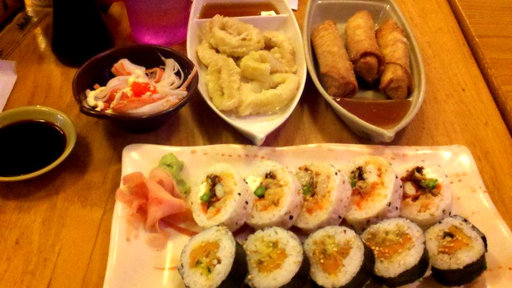

In [5]:
# Visualize an image
import random 
from PIL import Image

# Set seed
# random.seed(42)

# 1. Get all image paths 
image_path_list = list(image_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_image_path = random.choice(image_path_list)

# 3. Get image class from path name (the image class is the name of the directory where the image is stored)
image_class = random_image_path.parent.stem

# 4. Open image
img = Image.open(random_image_path)

# 5. Print metadata 
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

(np.float64(-0.5), np.float64(511.5), np.float64(287.5), np.float64(-0.5))

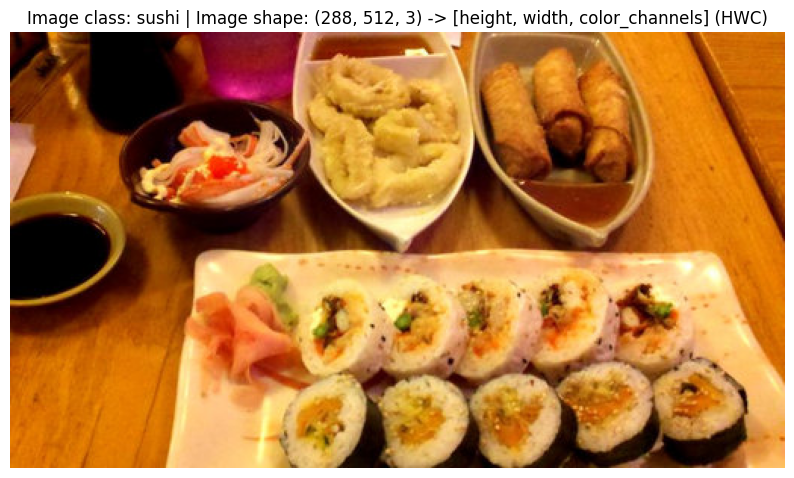

In [6]:
# Do the image visualization with matplotlib
import numpy as np
import matplotlib.pyplot as plt

# Turn the image into an array
img_as_array = np.asarray(img)

# Plot the image with matplotlib
plt.figure(figsize=(10, 7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape} -> [height, width, color_channels] (HWC)")
plt.axis(False)

We've got some images in our folders.

Now we need to make them compatible with PyTorch by:
1. Transform the data into tensors.
2. Turn the tensor data into a `torch.utils.data.Dataset` and later a `torch.utils.data.DataLoader`.

In [7]:
# 3.1 Transforming data with torchvision.transforms
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

data_transform = transforms.Compose([
    transforms.Resize(size=(64, 64)),
    transforms.ToTensor()
])

In [8]:
# Write transform for turning images into tensors
train_data = datasets.ImageFolder(
    root=train_dir,
    transform=data_transform,
    target_transform=None
)

test_data = datasets.ImageFolder(
    root=test_dir,
    transform=data_transform,
    target_transform=None
)

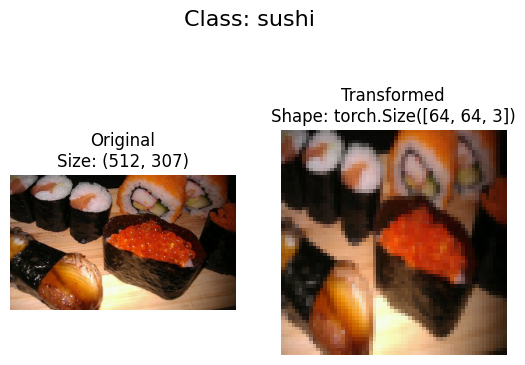

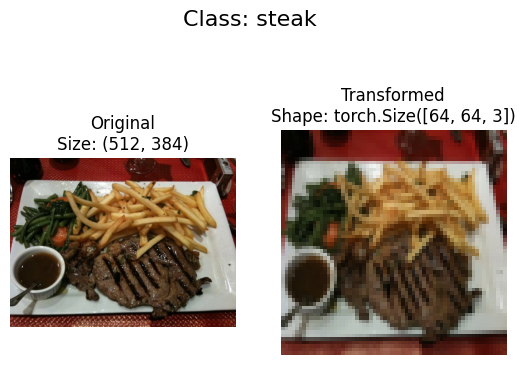

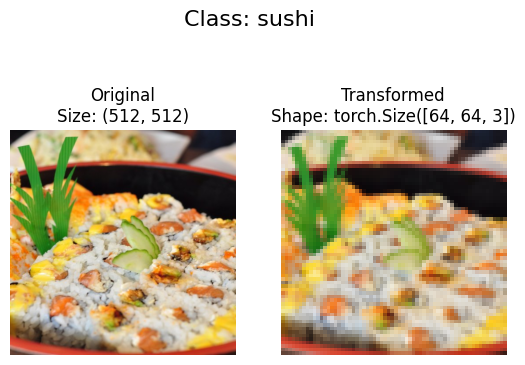

In [9]:
# Write a function to plot transformed images
def plot_transformed_images(image_paths: list, transform, n=3, seed=None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k=n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows=1, ncols=2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize: {f.size}")
      ax[0].axis(False)

      # Transform and plot target image
      transformed_image = transform(f).permute(1, 2, 0) # note we will need to change shape for matplotlib (C, H, W) -> (H, W, C)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)

plot_transformed_images(image_paths=image_path_list,
                        transform=data_transform,
                        n=3,
                        seed=None)

### Load image data using `ImageFolder`

In [10]:
# Use ImageFolder to create dataset(s)


In [11]:
# Get class names as a list
class_names = train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [12]:
# Can also get class names as a dict
class_dict = train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [13]:
# Check the lengths of each dataset
len(train_data), len(test_data)

(225, 75)

In [14]:
# Turn train and test Datasets into DataLoaders
from torch.utils.data import DataLoader
BATCH_SIZE = 1

train_dataloader = DataLoader(dataset=train_data,
                              batch_size=BATCH_SIZE,
                              num_workers=1,
                             shuffle=True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size=BATCH_SIZE,
                             num_workers=1,
                             shuffle=False)

In [15]:
(len(train_data) / BATCH_SIZE)

225.0

In [16]:
# How many batches of images are in our data loaders?
import math

print(len(train_data))
print(len(test_data))

print(BATCH_SIZE)

print(len(train_dataloader))
print(len(test_dataloader))

print(math.ceil(len(train_data) / BATCH_SIZE) == len(train_dataloader))
print(math.ceil(len(test_data) / BATCH_SIZE) == len(test_dataloader))

225
75
1
225
75
True
True


## 3. Recreate `model_0` we built in section 7 of notebook 04.

In [17]:
from torch import nn

In [18]:
class TinyVGG(nn.Module):
    def __init__(self, input_shape, hidden_units, output_shape):
        super().__init__()

        self.conv1_block1 = nn.Sequential(
            nn.Conv2d(in_channels=input_shape, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.conv1_block2 = nn.Sequential(
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=hidden_units, out_channels=hidden_units, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=hidden_units*16*16, out_features=output_shape)
        )

    def forward(self, x):
        x = self.conv1_block1(x)
        x = self.conv1_block2(x)
        x = self.classifier(x)
        return x

In [19]:
model = TinyVGG(input_shape=3, hidden_units=10, output_shape=len(class_names))

In [20]:
x = torch.rand(size=(BATCH_SIZE, 3, 64, 64))

x = model.conv1_block1(x)
print(x.shape)

x = model.conv1_block2(x)
print(x.shape)

torch.Size([1, 10, 32, 32])
torch.Size([1, 10, 16, 16])


In [21]:
!pip install torchinfo


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from torchinfo import summary

In [23]:
summary(model, input_size=[1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 32, 32]           --
│    └─Conv2d: 2-1                       [1, 10, 64, 64]           280
│    └─ReLU: 2-2                         [1, 10, 64, 64]           --
│    └─Conv2d: 2-3                       [1, 10, 64, 64]           910
│    └─ReLU: 2-4                         [1, 10, 64, 64]           --
│    └─MaxPool2d: 2-5                    [1, 10, 32, 32]           --
├─Sequential: 1-2                        [1, 10, 16, 16]           --
│    └─Conv2d: 2-6                       [1, 10, 32, 32]           910
│    └─ReLU: 2-7                         [1, 10, 32, 32]           --
│    └─Conv2d: 2-8                       [1, 10, 32, 32]           910
│    └─ReLU: 2-9                         [1, 10, 32, 32]           --
│    └─MaxPool2d: 2-10                   [1, 10, 16, 16]           --
├─Sequentia

## 4. Create training and testing functions for `model_0`.

In [24]:
loss_fn = nn.CrossEntropyLoss()

def accuracy_func(y_pred, y_true):
    correct = torch.eq(y_true, y_pred).sum().item()
    acc = (correct / len(y_pred)) * 100
    return acc


optimizer = torch.optim.Adam(params=model.parameters(), lr=0.001)

In [25]:
def train_step(model, dataloader, loss_fn, acc_func, optimizer):
    model.train()

    train_loss, train_acc = 0, 0

    for (x, y) in dataloader:
        x, y = x.to(device), y.to(device)

        y_logits = model(x)

        y_pred = torch.argmax(y_logits, dim=1)

        loss = loss_fn(y_logits, y)
        train_loss += loss.item()
        train_acc += acc_func(y_pred, y)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

    train_loss /= len(dataloader)
    train_acc /= len(dataloader)
    return train_loss, train_acc

In [26]:
def test_step(model, dataloader, loss_fn, acc_func):
    test_loss, test_acc = 0, 0

    model.eval()
    with torch.inference_mode():
        for (x, y) in dataloader:
            x, y = x.to(device), y.to(device)

            test_logits = model(x)

            y_pred = torch.argmax(test_logits, dim=1)

            loss = loss_fn(test_logits, y)
            test_loss += loss.item()
            test_acc += acc_func(y_pred, y)

    test_loss /= len(dataloader)
    test_acc /= len(dataloader)
    return test_loss, test_acc

In [27]:
def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module = nn.CrossEntropyLoss(),
          acc_func=None,
          epochs: int = 5):
  
    results = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    for epoch in range(epochs):

        train_loss, train_acc = train_step(
            model=model,
            dataloader=train_dataloader,
            loss_fn=loss_fn,
            optimizer=optimizer,
            acc_func=acc_func
        )

        test_loss, test_acc = test_step(
            model=model,
            dataloader=test_dataloader,
            loss_fn=loss_fn,
            acc_func=acc_func
        )

        print(
            f"Epoch: {epoch+1} | "
            f"train_loss: {train_loss:.4f} | "
            f"train_acc: {train_acc:.4f} | "
            f"test_loss: {test_loss:.4f} | "
            f"test_acc: {test_acc:.4f}"
        )

        results["train_loss"].append(train_loss)
        results["train_acc"].append(train_acc)
        results["test_loss"].append(test_loss)
        results["test_acc"].append(test_acc)

    return results

## 5. Try training the model you made in exercise 3 for 5, 20 and 50 epochs, what happens to the results?

In [28]:
# Train for 5 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 5

train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    acc_func=accuracy_func,
    epochs=epochs
)

Epoch: 1 | train_loss: 1.1156 | train_acc: 37.3333 | test_loss: 1.1037 | test_acc: 25.3333
Epoch: 2 | train_loss: 1.0992 | train_acc: 29.3333 | test_loss: 1.1028 | test_acc: 25.3333
Epoch: 3 | train_loss: 1.0989 | train_acc: 30.6667 | test_loss: 1.1029 | test_acc: 21.3333
Epoch: 4 | train_loss: 1.0987 | train_acc: 32.0000 | test_loss: 1.1025 | test_acc: 33.3333
Epoch: 5 | train_loss: 1.0987 | train_acc: 34.6667 | test_loss: 1.1029 | test_acc: 33.3333


{'train_loss': [1.1156387882762484,
  1.0992478826310899,
  1.0989486344655355,
  1.0987436490588718,
  1.0986769188774956],
 'train_acc': [37.333333333333336,
  29.333333333333332,
  30.666666666666668,
  32.0,
  34.666666666666664],
 'test_loss': [1.1037459754943848,
  1.102783098220825,
  1.1029315614700317,
  1.1025223382314047,
  1.102853414217631],
 'test_acc': [25.333333333333332,
  25.333333333333332,
  21.333333333333332,
  33.333333333333336,
  33.333333333333336]}

In [29]:
# Train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 20

train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    acc_func=accuracy_func,
    epochs=epochs
)

Epoch: 1 | train_loss: 1.0988 | train_acc: 34.2222 | test_loss: 1.1025 | test_acc: 33.3333
Epoch: 2 | train_loss: 1.0953 | train_acc: 32.8889 | test_loss: 1.1498 | test_acc: 29.3333
Epoch: 3 | train_loss: 1.1082 | train_acc: 32.8889 | test_loss: 1.1023 | test_acc: 33.3333
Epoch: 4 | train_loss: 1.0984 | train_acc: 34.2222 | test_loss: 1.1017 | test_acc: 33.3333
Epoch: 5 | train_loss: 1.1151 | train_acc: 38.6667 | test_loss: 1.1030 | test_acc: 33.3333
Epoch: 6 | train_loss: 1.0971 | train_acc: 36.0000 | test_loss: 1.1016 | test_acc: 33.3333
Epoch: 7 | train_loss: 1.0883 | train_acc: 42.2222 | test_loss: 1.0643 | test_acc: 45.3333
Epoch: 8 | train_loss: 1.0093 | train_acc: 56.8889 | test_loss: 0.9885 | test_acc: 52.0000
Epoch: 9 | train_loss: 0.9159 | train_acc: 56.0000 | test_loss: 0.9583 | test_acc: 46.6667
Epoch: 10 | train_loss: 0.8407 | train_acc: 61.3333 | test_loss: 0.9673 | test_acc: 53.3333
Epoch: 11 | train_loss: 0.7719 | train_acc: 64.4444 | test_loss: 0.9766 | test_acc: 52.00

{'train_loss': [1.098765384886,
  1.0953279304504395,
  1.108185803062386,
  1.098447602589925,
  1.1150804935561287,
  1.0971126948462593,
  1.088285694387224,
  1.009303285347091,
  0.9159058077798949,
  0.8406920834630728,
  0.7719161465908918,
  0.76723626429629,
  0.7327510176247193,
  0.6636069116327498,
  0.6370998393454486,
  0.5875811523232712,
  0.5357513097704699,
  0.4722199242701754,
  0.4139962374982942,
  0.34489277097939824],
 'train_acc': [34.22222222222222,
  32.888888888888886,
  32.888888888888886,
  34.22222222222222,
  38.666666666666664,
  36.0,
  42.22222222222222,
  56.888888888888886,
  56.0,
  61.333333333333336,
  64.44444444444444,
  65.33333333333333,
  68.44444444444444,
  72.44444444444444,
  72.44444444444444,
  75.55555555555556,
  73.77777777777777,
  84.88888888888889,
  83.55555555555556,
  88.44444444444444],
 'test_loss': [1.1024821027119955,
  1.1497504504521687,
  1.1022754716873169,
  1.101732169787089,
  1.1030167802174886,
  1.101585114796956

The model starts to overfit: training accuracy keeps increasing while test accuracy decreases, and test loss rises.

In [30]:
# Train for 50 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 50

train(
    model=model,
    train_dataloader=train_dataloader,
    test_dataloader=test_dataloader,
    optimizer=optimizer,
    loss_fn=loss_fn,
    acc_func=accuracy_func,
    epochs=epochs
)

Epoch: 1 | train_loss: 0.2872 | train_acc: 92.4444 | test_loss: 1.4281 | test_acc: 46.6667
Epoch: 2 | train_loss: 0.1984 | train_acc: 93.7778 | test_loss: 1.5963 | test_acc: 49.3333
Epoch: 3 | train_loss: 0.1650 | train_acc: 95.5556 | test_loss: 1.8987 | test_acc: 45.3333
Epoch: 4 | train_loss: 0.1020 | train_acc: 96.4444 | test_loss: 2.0041 | test_acc: 46.6667
Epoch: 5 | train_loss: 0.1033 | train_acc: 96.8889 | test_loss: 2.3504 | test_acc: 41.3333
Epoch: 6 | train_loss: 0.0631 | train_acc: 98.2222 | test_loss: 2.1917 | test_acc: 45.3333
Epoch: 7 | train_loss: 0.0341 | train_acc: 99.5556 | test_loss: 2.4844 | test_acc: 45.3333
Epoch: 8 | train_loss: 0.0168 | train_acc: 100.0000 | test_loss: 2.6860 | test_acc: 46.6667
Epoch: 9 | train_loss: 0.0142 | train_acc: 99.5556 | test_loss: 2.7692 | test_acc: 46.6667
Epoch: 10 | train_loss: 0.0071 | train_acc: 100.0000 | test_loss: 2.9274 | test_acc: 48.0000
Epoch: 11 | train_loss: 0.0046 | train_acc: 100.0000 | test_loss: 2.9505 | test_acc: 46

{'train_loss': [0.28715380813519004,
  0.1984128852008305,
  0.16504623276054595,
  0.10198403124538648,
  0.1032650376883627,
  0.06312163785127811,
  0.034106474134062176,
  0.016783671882141298,
  0.014236901526913136,
  0.0071129759635865895,
  0.004649944399546497,
  0.003160191059563399,
  0.002232785297968923,
  0.0017487590230794896,
  0.0013006399508399605,
  0.001037874083441655,
  0.0008207075066828098,
  0.0006456472148933775,
  0.000526236795177542,
  0.0004396644733470288,
  0.00035007148876448784,
  0.000291712686287945,
  0.00023936797411522548,
  0.00020180634821091164,
  0.0001683554384926664,
  0.00014046105095205676,
  0.00011224161668915636,
  9.274643181167146e-05,
  7.868068157560199e-05,
  6.748540020566907e-05,
  5.603544585843186e-05,
  4.4861575912686175e-05,
  3.73721221082077e-05,
  3.0336420282582014e-05,
  2.628307481438065e-05,
  2.0630117728488685e-05,
  1.6906899180197697e-05,
  1.4169551237065055e-05,
  1.2191826018989913e-05,
  9.457049088186725e-06,

It looks like our model is starting to overfit towards the end (performing far better on the training data than on the testing data).

In order to fix this, we'd have to introduce ways of preventing overfitting.

## 6. Double the number of hidden units in your model and train it for 20 epochs, what happens to the results?

In [34]:
# Double the number of hidden units and train for 20 epochs
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 20

model_1 = TinyVGG(input_shape=3, hidden_units=20, output_shape=len(class_names))

optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

train(model=model_1, train_dataloader=train_dataloader, test_dataloader=test_dataloader, optimizer=optimizer, loss_fn=loss_fn, acc_func=accuracy_func, epochs=epochs)

Epoch: 1 | train_loss: 1.0943 | train_acc: 39.1111 | test_loss: 1.0817 | test_acc: 37.3333
Epoch: 2 | train_loss: 1.0278 | train_acc: 44.0000 | test_loss: 1.0596 | test_acc: 42.6667
Epoch: 3 | train_loss: 0.9672 | train_acc: 56.4444 | test_loss: 0.9716 | test_acc: 50.6667
Epoch: 4 | train_loss: 0.8712 | train_acc: 61.3333 | test_loss: 0.9907 | test_acc: 52.0000
Epoch: 5 | train_loss: 0.8662 | train_acc: 60.4444 | test_loss: 1.0382 | test_acc: 38.6667
Epoch: 6 | train_loss: 0.8505 | train_acc: 64.4444 | test_loss: 1.0228 | test_acc: 45.3333
Epoch: 7 | train_loss: 0.7582 | train_acc: 67.5556 | test_loss: 1.1288 | test_acc: 49.3333
Epoch: 8 | train_loss: 0.6705 | train_acc: 71.5556 | test_loss: 1.1734 | test_acc: 42.6667
Epoch: 9 | train_loss: 0.5744 | train_acc: 77.3333 | test_loss: 1.2960 | test_acc: 41.3333
Epoch: 10 | train_loss: 0.4663 | train_acc: 80.0000 | test_loss: 1.7304 | test_acc: 44.0000
Epoch: 11 | train_loss: 0.3906 | train_acc: 85.7778 | test_loss: 1.5681 | test_acc: 44.00

{'train_loss': [1.0943448173999786,
  1.0278023826579252,
  0.96717971333613,
  0.8711749531307982,
  0.8661697360583478,
  0.8505443603669604,
  0.7581707106199529,
  0.6705367179628876,
  0.5743872262275544,
  0.46625109550129207,
  0.3906406741436513,
  0.27667195246967824,
  0.13321796934891458,
  0.08895188605474633,
  0.10736889077415236,
  0.2479097745578679,
  0.1602586710471724,
  0.19181707504920617,
  0.09054816816807204,
  0.0318489814167422],
 'train_acc': [39.111111111111114,
  44.0,
  56.44444444444444,
  61.333333333333336,
  60.44444444444444,
  64.44444444444444,
  67.55555555555556,
  71.55555555555556,
  77.33333333333333,
  80.0,
  85.77777777777777,
  92.0,
  95.11111111111111,
  96.44444444444444,
  96.88888888888889,
  92.88888888888889,
  93.77777777777777,
  94.66666666666667,
  95.55555555555556,
  99.55555555555556],
 'test_loss': [1.081673002243042,
  1.0596328844130039,
  0.9716224038600921,
  0.9907309792935848,
  1.0381592995921771,
  1.022791806384921,


It looks like the model is still overfitting, even when changing the number of hidden units.

To fix this, we'd have to look at ways to prevent overfitting with our model.

## 7. Double the data you're using with your model from step 6 and train it for 20 epochs, what happens to the results?
* **Note:** You can use the [custom data creation notebook](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/04_custom_data_creation.ipynb) to scale up your Food101 dataset.
* You can also find the [already formatted double data (20% instead of 10% subset) dataset on GitHub](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/data/pizza_steak_sushi_20_percent.zip), you will need to write download code like in exercise 2 to get it into this notebook.

In [36]:
import zipfile
from pathlib import Path

data_path = Path("data/")
image_path_20 = data_path / "pizza_steak_sushi_20_percent"

image_path_20.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(
    data_path / "pizza_steak_sushi_20_percent.zip", "r"
) as zip_ref:
    zip_ref.extractall(image_path_20)

In [37]:
# See how many images we have
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data\pizza_steak_sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\test'.
There are 0 directories and 25 images in 'data\pizza_steak_sushi\test\pizza'.
There are 0 directories and 19 images in 'data\pizza_steak_sushi\test\steak'.
There are 0 directories and 31 images in 'data\pizza_steak_sushi\test\sushi'.
There are 3 directories and 0 images in 'data\pizza_steak_sushi\train'.
There are 0 directories and 78 images in 'data\pizza_steak_sushi\train\pizza'.
There are 0 directories and 75 images in 'data\pizza_steak_sushi\train\steak'.
There are 0 directories and 72 images in 'data\pizza_steak_sushi\train\sushi'.


Excellent, we now have double the training and testing images... 

In [38]:
# Create the train and test paths
train_dir_20 = image_path_20 / "train"
test_dir_20 = image_path_20 / "test"

train_dir_20, test_dir_20

(WindowsPath('data/pizza_steak_sushi_20_percent/train'),
 WindowsPath('data/pizza_steak_sushi_20_percent/test'))

In [39]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

simple_transform = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

train_data_20 = datasets.ImageFolder(
    root=train_dir_20,
    transform=simple_transform
)

test_data_20 = datasets.ImageFolder(
    root=test_dir_20,
    transform=simple_transform
)

train_dataloader_20 = DataLoader(
    train_data_20,
    batch_size=32,
    shuffle=True,
    num_workers=0
)

test_dataloader_20 = DataLoader(
    test_data_20,
    batch_size=32,
    shuffle=False,
    num_workers=0
)

In [40]:
# Train a model with increased amount of data
torch.manual_seed(42)
torch.cuda.manual_seed(42)

torch.manual_seed(42)

model_1 = TinyVGG(input_shape=3, hidden_units=20, output_shape=len(train_data_20.classes)).to(device)

loss_fn = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model_1.parameters(), lr=0.001)

In [41]:
results_20 = train(
    model=model_1,
    train_dataloader=train_dataloader_20,
    test_dataloader=test_dataloader_20,
    optimizer=optimizer,
    loss_fn=loss_fn,
    acc_func=accuracy_func,
    epochs=20
)

Epoch: 1 | train_loss: 1.1042 | train_acc: 33.1250 | test_loss: 1.1004 | test_acc: 28.7500
Epoch: 2 | train_loss: 1.0833 | train_acc: 39.1667 | test_loss: 1.0688 | test_acc: 44.0909
Epoch: 3 | train_loss: 1.0268 | train_acc: 45.8333 | test_loss: 0.9480 | test_acc: 56.3068
Epoch: 4 | train_loss: 0.9206 | train_acc: 54.3750 | test_loss: 0.9124 | test_acc: 55.3977
Epoch: 5 | train_loss: 0.8559 | train_acc: 62.9167 | test_loss: 0.9008 | test_acc: 54.9432
Epoch: 6 | train_loss: 0.8348 | train_acc: 64.3750 | test_loss: 1.0072 | test_acc: 48.6932
Epoch: 7 | train_loss: 0.8968 | train_acc: 56.6667 | test_loss: 0.8867 | test_acc: 57.8409
Epoch: 8 | train_loss: 0.7566 | train_acc: 70.4167 | test_loss: 0.9198 | test_acc: 61.0795
Epoch: 9 | train_loss: 0.7759 | train_acc: 64.5833 | test_loss: 0.8840 | test_acc: 59.3182
Epoch: 10 | train_loss: 0.7681 | train_acc: 68.1250 | test_loss: 0.8548 | test_acc: 61.5909
Epoch: 11 | train_loss: 0.7216 | train_acc: 71.2500 | test_loss: 0.8637 | test_acc: 64.77

## 8. Make a prediction on your own custom image of pizza/steak/sushi (you could even download one from the internet) with your trained model from exercise 7 and share your prediction. 
* Does the model you trained in exercise 7 get it right? 
* If not, what do you think you could do to improve it?

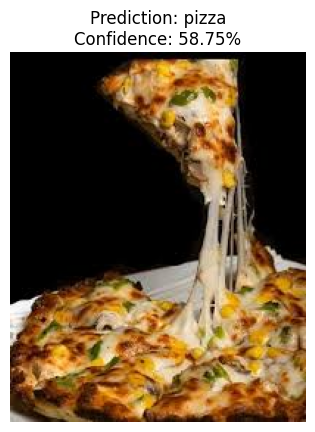

In [44]:
from PIL import Image
import matplotlib.pyplot as plt
import torch

custom_image_path = "data/my_pizza.jpeg" 

custom_image = Image.open(custom_image_path).convert("RGB")

custom_image_transformed = simple_transform(custom_image)

# [C, H, W] -> [1, C, H, W]
custom_image_transformed = custom_image_transformed.unsqueeze(0).to(device)

# 4. Prediction
model_1.eval()

with torch.inference_mode():
    logits = model_1(custom_image_transformed)

    pred_probs = torch.softmax(logits, dim=1)
    pred_class = pred_probs.argmax(dim=1).item()
    confidence = pred_probs[0, pred_class].item()

# 5. نمایش نتیجه
plt.imshow(custom_image)
plt.title(
    f"Prediction: {train_data_20.classes[pred_class]}\n"
    f"Confidence: {confidence*100:.2f}%"
)
plt.axis("off")
plt.show()